# **cell 1 :Install Libraries**

In [1]:
!pip install yfinance pandas numpy

# **📋 Cell 2: Fetch Stock Data**

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import sqlite3
from datetime import datetime

# NIFTY 50 top 10 stocks
tickers = [
    'RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS', 'ICICIBANK.NS',
    'HINDUNILVR.NS', 'ITC.NS', 'SBIN.NS', 'BHARTIARTL.NS', 'KOTAKBANK.NS'
]

print("📥 Downloading 2 years of stock data...\n")

all_data = []
for ticker in tickers:
    try:
        df = yf.download(ticker, period='2y', interval='1d', progress=False, auto_adjust=True)

        # ✅ Fix: Flatten MultiIndex columns
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        df = df.reset_index()
        df['Ticker'] = ticker
        all_data.append(df)
        print(f"✅ {ticker}: {len(df)} rows")
    except Exception as e:
        print(f"❌ {ticker}: {e}")

combined = pd.concat(all_data, ignore_index=True)
print(f"\n📊 Total records: {len(combined)}")
print(f"📋 Columns: {combined.columns.tolist()}")
combined.head()

📥 Downloading 2 years of stock data...

✅ RELIANCE.NS: 499 rows
✅ TCS.NS: 499 rows
✅ INFY.NS: 499 rows
✅ HDFCBANK.NS: 499 rows
✅ ICICIBANK.NS: 499 rows
✅ HINDUNILVR.NS: 498 rows
✅ ITC.NS: 499 rows
✅ SBIN.NS: 499 rows
✅ BHARTIARTL.NS: 499 rows
✅ KOTAKBANK.NS: 499 rows

📊 Total records: 4989
📋 Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker']


Price,Date,Close,High,Low,Open,Volume,Ticker
0,2024-09-16,1458.752319,1468.220601,1452.208853,1464.899308,5481774,RELIANCE.NS
1,2024-09-17,1459.694214,1464.824833,1454.067755,1461.379610,5935328,RELIANCE.NS
2,2024-09-18,1450.919800,1469.311022,1448.044727,1457.413767,8574714,RELIANCE.NS
3,2024-09-19,1457.091675,1463.858191,1443.087613,1453.695951,16955902,RELIANCE.NS
4,2024-09-20,1473.202515,1482.199766,1458.777044,1461.379568,30897320,RELIANCE.NS


# **📋 Cell 3: Save to SQLite Database**

In [5]:
# Save to SQLite
conn = sqlite3.connect('stock_data.db')
combined.to_sql('stocks', conn, if_exists='replace', index=False)

# Verify
verify = pd.read_sql("""
    SELECT Ticker, COUNT(*) as rows, MIN(Date) as start_date, MAX(Date) as end_date
    FROM stocks GROUP BY Ticker
""", conn)
conn.close()

print("📁 Database saved: stock_data.db\n")
print(verify.to_string(index=False))

📁 Database saved: stock_data.db

       Ticker  rows          start_date            end_date
BHARTIARTL.NS   499 2024-09-16 00:00:00 2026-09-15 00:00:00
  HDFCBANK.NS   499 2024-09-16 00:00:00 2026-09-15 00:00:00
HINDUNILVR.NS   498 2024-09-16 00:00:00 2026-09-15 00:00:00
 ICICIBANK.NS   499 2024-09-16 00:00:00 2026-09-15 00:00:00
      INFY.NS   499 2024-09-16 00:00:00 2026-09-15 00:00:00
       ITC.NS   499 2024-09-16 00:00:00 2026-09-15 00:00:00
 KOTAKBANK.NS   499 2024-09-16 00:00:00 2026-09-15 00:00:00
  RELIANCE.NS   499 2024-09-16 00:00:00 2026-09-15 00:00:00
      SBIN.NS   499 2024-09-16 00:00:00 2026-09-15 00:00:00
       TCS.NS   499 2024-09-16 00:00:00 2026-09-15 00:00:00


# **📋 Cell 4: Compute Technical Indicators**

In [6]:
# RSI calculator
def compute_rsi(prices, period=14):
    delta = prices.diff()
    gain = delta.where(delta > 0, 0).rolling(period).mean()
    loss = -delta.where(delta < 0, 0).rolling(period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

# Load RELIANCE data
conn = sqlite3.connect('stock_data.db')
df = pd.read_sql('SELECT * FROM stocks WHERE Ticker = "RELIANCE.NS"', conn)
conn.close()

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Indicators
df['SMA_20'] = df['Close'].rolling(20).mean()
df['SMA_50'] = df['Close'].rolling(50).mean()
df['RSI'] = compute_rsi(df['Close'], 14)
df['Daily_Return'] = df['Close'].pct_change()
df['Volatility'] = df['Daily_Return'].rolling(30).std()

print(f"📈 {len(df)} rows processed for RELIANCE.NS\n")
print(df[['Date', 'Close', 'SMA_20', 'SMA_50', 'RSI', 'Volatility']].tail(10).to_string(index=False))

📈 499 rows processed for RELIANCE.NS

      Date       Close      SMA_20      SMA_50       RSI  Volatility
2026-09-01 1309.000000 1310.260004 1303.352002 42.957746    0.011809
2026-09-02 1313.099976 1311.915002 1303.342002 48.545852    0.011606
2026-09-03 1302.500000 1310.790002 1303.030002 47.276687    0.011451
2026-09-04 1322.000000 1310.150000 1303.108003 51.984128    0.011722
2026-09-07 1309.500000 1309.259998 1303.278003 46.036777    0.011881
2026-09-08 1294.900024 1307.809998 1303.298003 45.009305    0.011931
2026-09-09 1279.000000 1305.309998 1302.718003 40.228585    0.012112
2026-09-10 1274.000000 1303.159998 1302.128003 38.148981    0.011872
2026-09-11 1257.500000 1300.534998 1301.198003 36.053320    0.011864
2026-09-15 1255.000000 1297.484998 1299.872002 33.041580    0.011719


# **📋 Cell 5: Visualize**

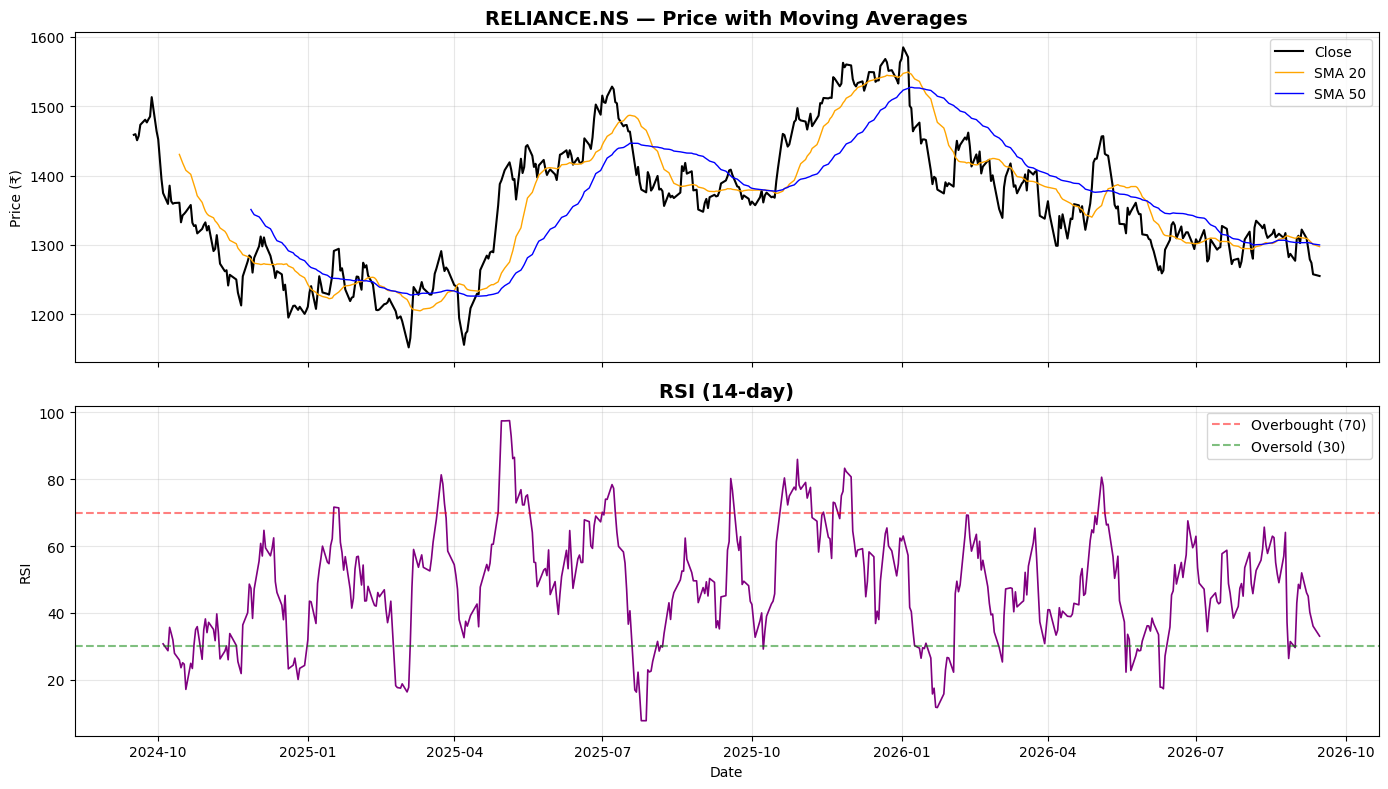

✅ Chart saved as reliance_analysis.png


In [7]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Price + SMAs
ax1.plot(df['Date'], df['Close'], label='Close', color='black', linewidth=1.5)
ax1.plot(df['Date'], df['SMA_20'], label='SMA 20', color='orange', linewidth=1)
ax1.plot(df['Date'], df['SMA_50'], label='SMA 50', color='blue', linewidth=1)
ax1.set_title('RELIANCE.NS — Price with Moving Averages', fontsize=14, fontweight='bold')
ax1.set_ylabel('Price (₹)')
ax1.legend()
ax1.grid(alpha=0.3)

# RSI
ax2.plot(df['Date'], df['RSI'], color='purple', linewidth=1.2)
ax2.axhline(70, color='red', linestyle='--', alpha=0.5, label='Overbought (70)')
ax2.axhline(30, color='green', linestyle='--', alpha=0.5, label='Oversold (30)')
ax2.set_title('RSI (14-day)', fontsize=14, fontweight='bold')
ax2.set_ylabel('RSI')
ax2.set_xlabel('Date')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('reliance_analysis.png', dpi=100)
plt.show()
print("✅ Chart saved as reliance_analysis.png")

# **📋 Cell 6: Summary Statistics**

In [8]:
# Summary for all stocks
conn = sqlite3.connect('stock_data.db')
summary = pd.read_sql("""
    SELECT
        Ticker,
        ROUND(AVG(Close), 2) AS avg_price,
        ROUND(MIN(Close), 2) AS min_price,
        ROUND(MAX(Close), 2) AS max_price,
        ROUND(AVG(Volume), 0) AS avg_volume
    FROM stocks
    GROUP BY Ticker
    ORDER BY Ticker
""", conn)
conn.close()

print("📊 Stock Summary:\n")
print(summary.to_string(index=False))

📊 Stock Summary:

       Ticker  avg_price  min_price  max_price  avg_volume
BHARTIARTL.NS    1820.28    1493.71    2135.82   7001284.0
  HDFCBANK.NS     869.94     687.10     996.42  27636362.0
HINDUNILVR.NS    2314.34    1927.00    2909.86   1717299.0
 ICICIBANK.NS    1335.67    1177.07    1464.85  12379094.0
      INFY.NS    1465.92     985.30    1901.08   9099231.0
       ITC.NS     363.15     255.50     463.95  16791994.0
 KOTAKBANK.NS     397.72     336.60     452.46  18202033.0
  RELIANCE.NS    1360.58    1151.95    1584.97  13139911.0
      SBIN.NS     886.70     663.29    1206.06  11952656.0
       TCS.NS    3056.92    1971.79    4193.08   3118334.0


# **📋 Cell 7: Download Files**

In [9]:
from google.colab import files

# Download database and chart
files.download('stock_data.db')
files.download('reliance_analysis.png')

print("✅ Files downloading to your laptop")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Files downloading to your laptop
